# Task 1: Business Sales Performance Analytics

## 1. Introduction

The objective of this project is to analyze business sales data to identify sales trends, top-selling products, and high-performing categories and regions. This analysis will help understand business performance and support data-driven decision-making.

## 2. Project Objectives

* Analyze sales and profit trends.
* Identify top-selling products and categories.
* Compare sales performance across different regions.
* Generate meaningful business insights and recommendations.

## 3. Tools and Technologies

* Python
* Google Colab
* Pandas
* Matplotlib and Seaborn
* Superstore Sales Dataset (CSV format)

## 4. Dataset Preparation

The dataset is provided in a ZIP file. It will be extracted, loaded into Python, and prepared for further analysis.


In [5]:

import zipfile
import os

zip_path = "/content/archive (5).zip"
extract_path = "/content/superstore_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")

print(os.listdir(extract_path))

ZIP extracted successfully!
['Sample - Superstore.csv']


In [6]:

import pandas as pd
import os

# Find the extracted CSV file
for root, dirs, files in os.walk("/content/superstore_data"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_path = os.path.join(root, file)
            print("Dataset found:", csv_path)

# Load the dataset
df = pd.read_csv(csv_path, encoding="latin1")

# Display the first five rows
display(df.head())

Dataset found: /content/superstore_data/Sample - Superstore.csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
print("Rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Rows and columns: (9994, 21)

Column names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null

Data Cleaning

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


In [7]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

print(df[['Order Date', 'Ship Date']].head())

print("\nUpdated data types:")
print(df[['Order Date', 'Ship Date']].dtypes)

  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-11-08 2016-11-11
2 2016-06-12 2016-06-16
3 2015-10-11 2015-10-18
4 2015-10-11 2015-10-18

Updated data types:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [9]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value, 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Average Order Value: 458.61


# Monthly Sales Trend Analysis

In this step, I will analyze monthly sales to understand how business performance changes over time. A line chart will be used to identify sales patterns and months with higher or lower sales.


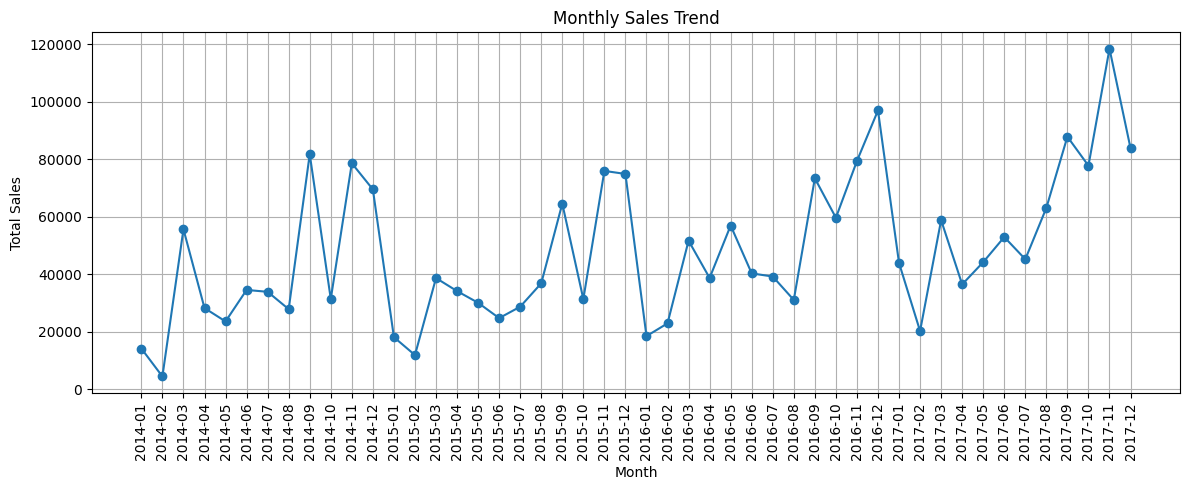

In [10]:

import matplotlib.pyplot as plt

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

#Category-wise Sales Analysis

In this step, I will compare sales across different product categories. This analysis will help identify which categories contribute the most to total sales and where the business can focus its efforts.


Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


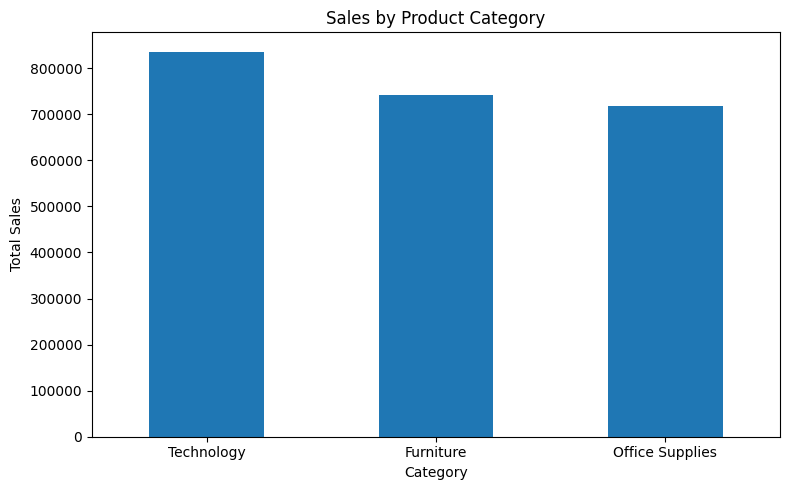

In [11]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Region-wise Sales Analysis

In this step, I will compare sales across different regions to understand the geographical performance of the business. This analysis will help identify strong-performing regions and areas where sales may need improvement.


Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


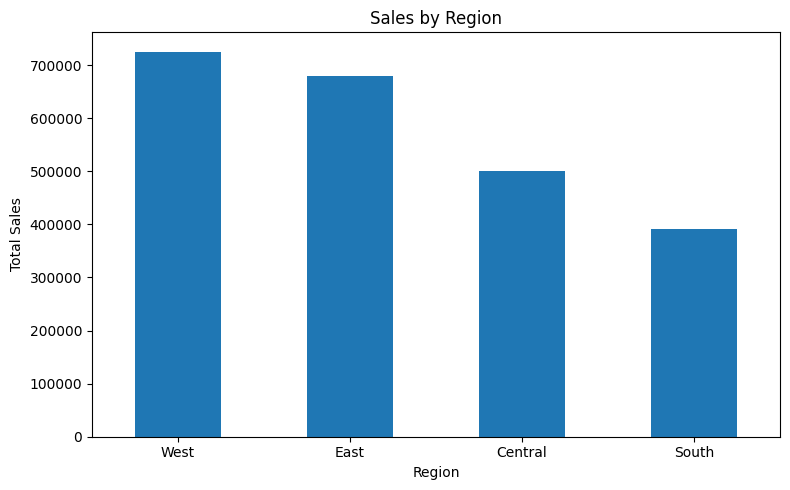

In [12]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


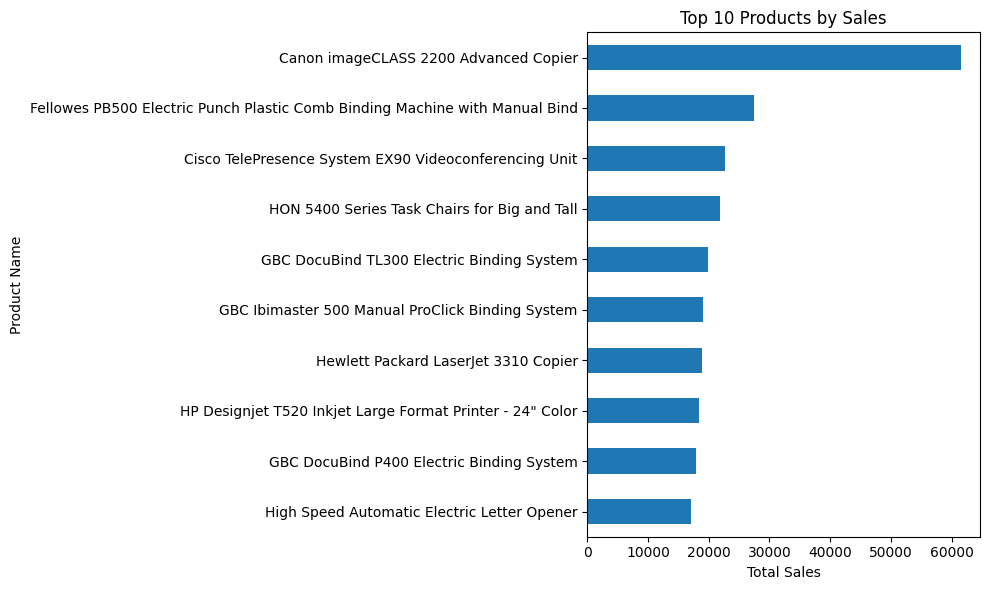

In [13]:
top_products = df.groupby('Product Name')['Sales'].sum()
top_products = top_products.sort_values(ascending=False).head(10)

print(top_products)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


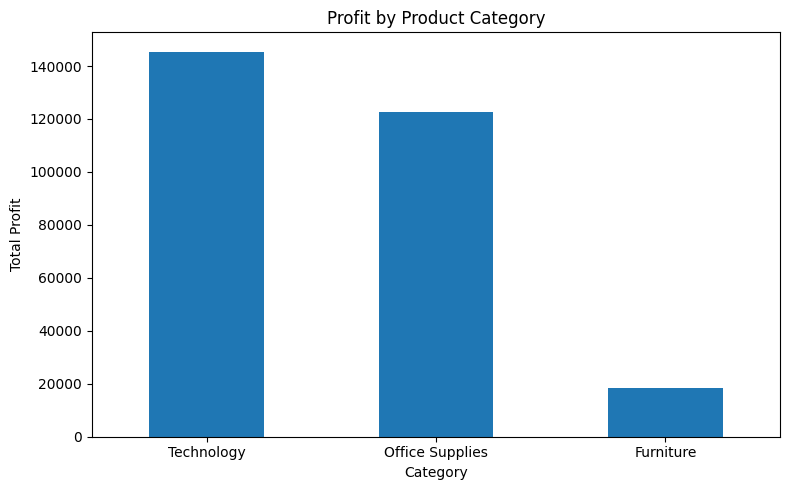

In [14]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit = category_profit.sort_values(ascending=False)

print(category_profit)

plt.figure(figsize=(8, 5))
category_profit.plot(kind='bar')

plt.title('Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


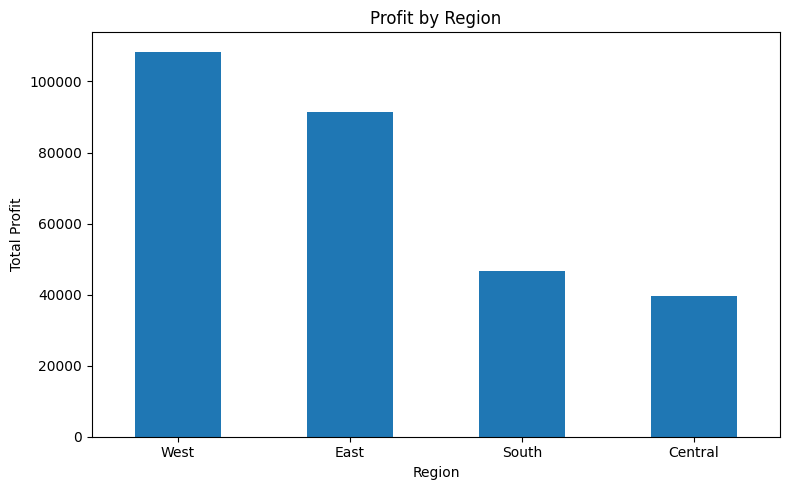

In [15]:
region_profit = df.groupby('Region')['Profit'].sum()
region_profit = region_profit.sort_values(ascending=False)

print(region_profit)

plt.figure(figsize=(8, 5))
region_profit.plot(kind='bar')

plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


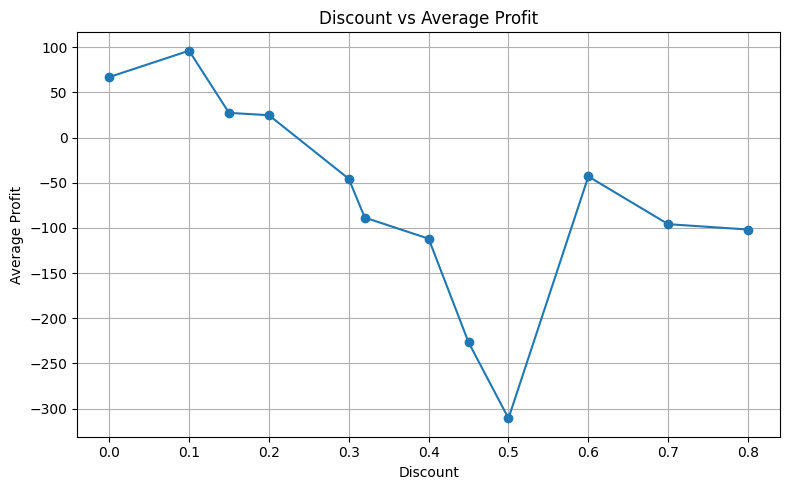

In [16]:
discount_profit = df.groupby('Discount')['Profit'].mean()

print(discount_profit)

plt.figure(figsize=(8, 5))
plt.plot(discount_profit.index, discount_profit.values, marker='o')

plt.title('Discount vs Average Profit')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
print("Highest Sales Category:")
print(category_sales.idxmax(), "-", round(category_sales.max(), 2))

print("\nHighest Profit Category:")
print(category_profit.idxmax(), "-", round(category_profit.max(), 2))

print("\nHighest Sales Region:")
print(region_sales.idxmax(), "-", round(region_sales.max(), 2))

print("\nHighest Profit Region:")
print(region_profit.idxmax(), "-", round(region_profit.max(), 2))

print("\nTop Selling Product by Sales:")
print(top_products.idxmax(), "-", round(top_products.max(), 2))

print("\nOverall Profit Margin (%):")
print(round((df['Profit'].sum() / df['Sales'].sum()) * 100, 2))

Highest Sales Category:
Technology - 836154.03

Highest Profit Category:
Technology - 145454.95

Highest Sales Region:
West - 725457.82

Highest Profit Region:
West - 108418.45

Top Selling Product by Sales:
Canon imageCLASS 2200 Advanced Copier - 61599.82

Overall Profit Margin (%):
12.47


##  Business Recommendations

Based on the analysis, the business can consider the following actions:

* Focus on product categories that generate strong sales and profit.
* Review the performance of regions with lower sales or profit.
* Monitor discount strategies to avoid reducing profit margins.
* Maintain sufficient stock of products that contribute significantly to sales.
* Track monthly sales trends to improve future planning and marketing decisions.

These recommendations should be reviewed alongside the actual results to ensure that business decisions are supported by the data.


# Conclusion

This project helped me understand business sales performance using Python and data analysis techniques. I explored sales trends, product categories, regional performance, profitability, and discount patterns using the Superstore dataset.

The analysis provides useful insights into business performance and highlights opportunities to improve sales planning, inventory management, and pricing strategies.

Overall, this project helped me gain practical experience in data cleaning, data visualization, and extracting meaningful insights from business data.


Sub-Category Sales and Profit Analysis


,Total_Sales,Total_Profit
Sub-Category,,
Copiers,149528.03,55617.82
Phones,330007.05,44515.73
Accessories,167380.32,41936.64
Paper,78479.21,34053.57
Binders,203412.73,30221.76
Chairs,328449.10,26590.17
Storage,223843.61,21278.83
Appliances,107532.16,18138.01
Furnishings,91705.16,13059.14


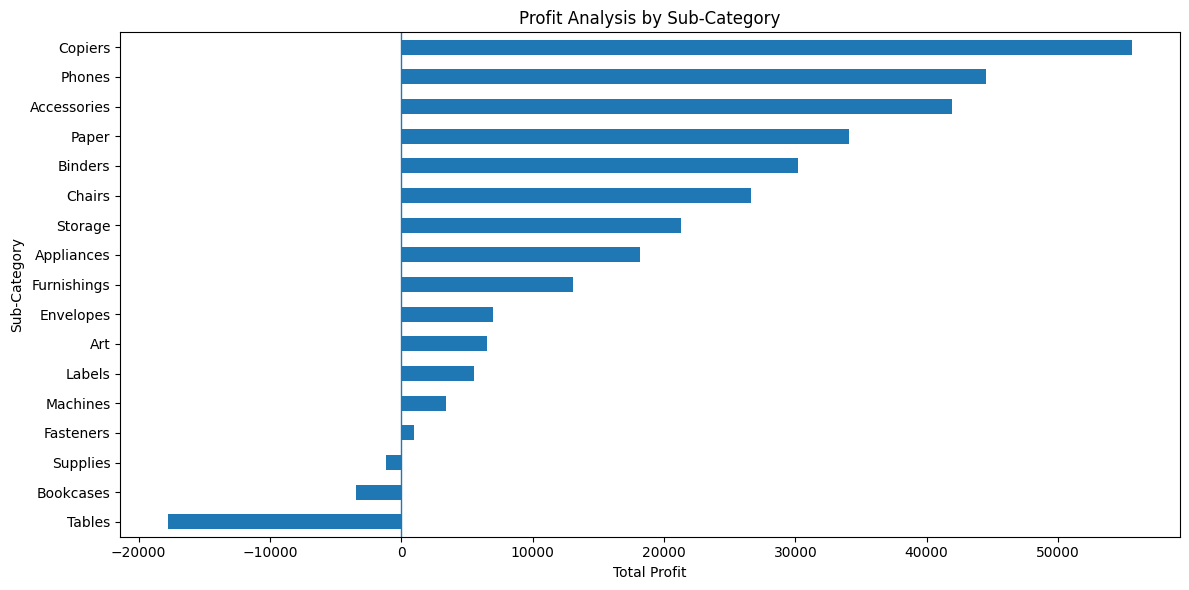

In [18]:
# Sub-Category Sales and Profit Analysis

import pandas as pd
import matplotlib.pyplot as plt

subcategory_analysis = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Profit', ascending=False)

print("Sub-Category Sales and Profit Analysis")
display(subcategory_analysis.round(2))

# Plot profit earned by each sub-category
plt.figure(figsize=(12, 6))

subcategory_analysis['Total_Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Profit Analysis by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.axvline(x=0, linewidth=1)
plt.tight_layout()
plt.show()

Discount Analysis


,Discount,Total_Sales,Total_Profit,Average_Profit
0,0.00,1087908.47,320987.60,66.90
1,0.10,54369.35,9029.18,96.06
2,0.15,27558.52,1418.99,27.29
3,0.20,764594.37,90337.31,24.70
4,0.30,103226.66,-10369.28,-45.68
5,0.32,14493.46,-2391.14,-88.56
6,0.40,116417.78,-23057.05,-111.93
7,0.45,5484.97,-2493.11,-226.65
8,0.50,58918.54,-20506.43,-310.70
9,0.60,6644.70,-5944.66,-43.08


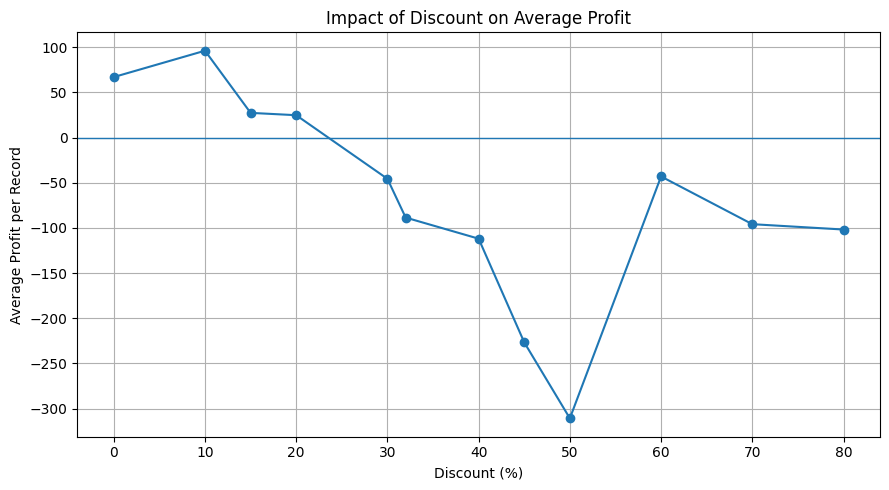

In [19]:

# Discount vs Profit Analysis

discount_analysis = df.groupby('Discount').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Average_Profit=('Profit', 'mean')
).reset_index()

print("Discount Analysis")
display(discount_analysis.round(2))

plt.figure(figsize=(9, 5))
plt.plot(
    discount_analysis['Discount'] * 100,
    discount_analysis['Average_Profit'],
    marker='o'
)

plt.title('Impact of Discount on Average Profit')
plt.xlabel('Discount (%)')
plt.ylabel('Average Profit per Record')
plt.axhline(y=0, linewidth=1)
plt.grid(True)
plt.tight_layout()
plt.show()

Top 10 Loss-Making Products


,Product Name,Total_Sales,Total_Profit
475,Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97
985,Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97
476,Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.64,-2876.12
376,Bush Advantage Collection Racetrack Conference...,9544.72,-1934.40
683,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17
444,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08
1043,Martin Yale Chadless Opener Electric Letter Op...,16656.20,-1299.18
285,Balt Solid Wood Round Tables,6518.75,-1201.06
364,BoxOffice By Design Rectangular and Half-Moon ...,1706.25,-1148.44


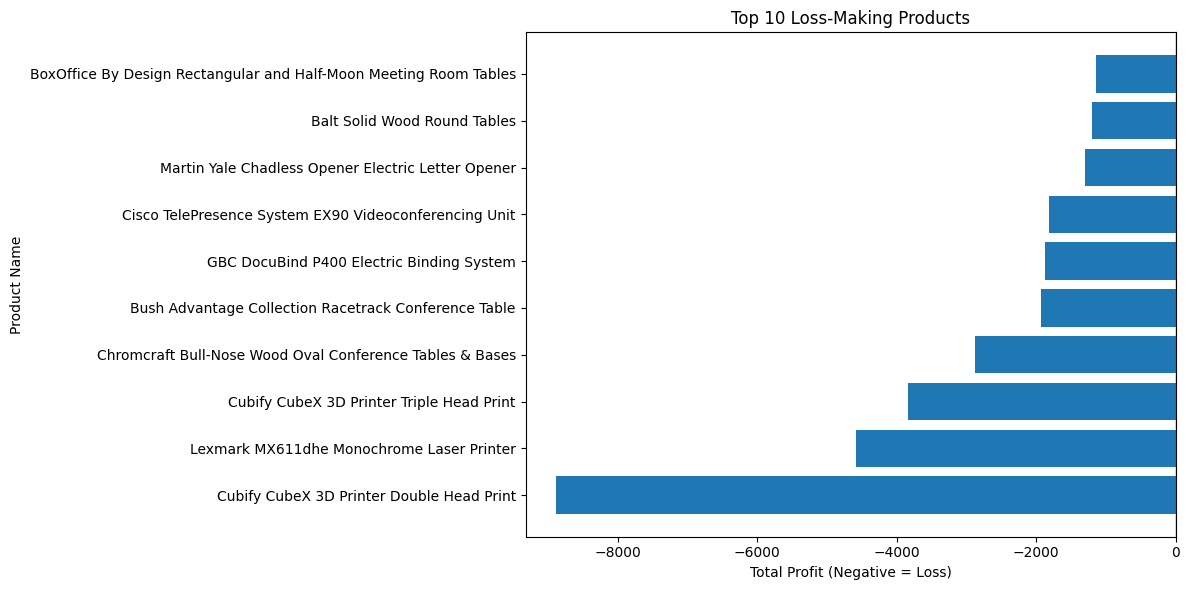

In [20]:

# Identify the Top 10 Loss-Making Products

product_profit = df.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

loss_products = product_profit[
    product_profit['Total_Profit'] < 0
].sort_values('Total_Profit').head(10)

print("Top 10 Loss-Making Products")
display(loss_products.round(2))

plt.figure(figsize=(12, 6))
plt.barh(
    loss_products['Product Name'],
    loss_products['Total_Profit']
)

plt.title('Top 10 Loss-Making Products')
plt.xlabel('Total Profit (Negative = Loss)')
plt.ylabel('Product Name')
plt.axvline(x=0, linewidth=1)
plt.tight_layout()
plt.show()

Regional Performance Analysis


,Total_Sales,Total_Profit,Total_Orders
Region,,,
West,725457.82,108418.45,1611
East,678781.24,91522.78,1401
South,391721.90,46749.43,822
Central,501239.89,39706.36,1175


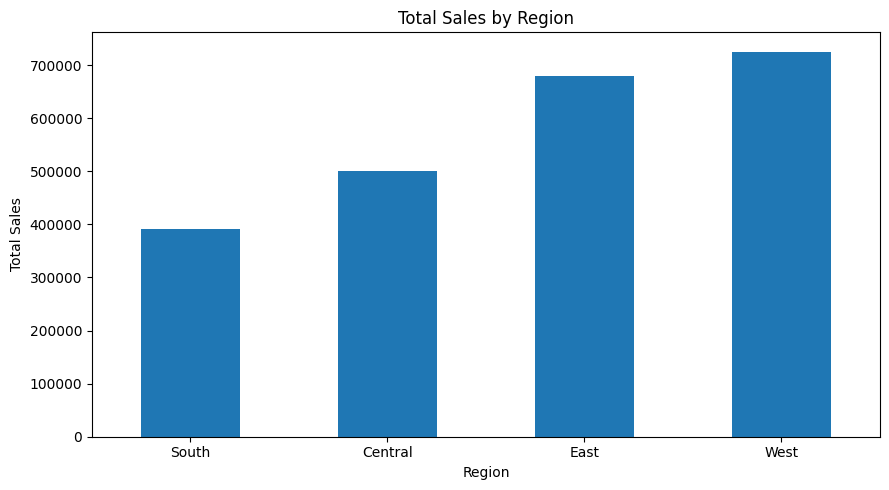

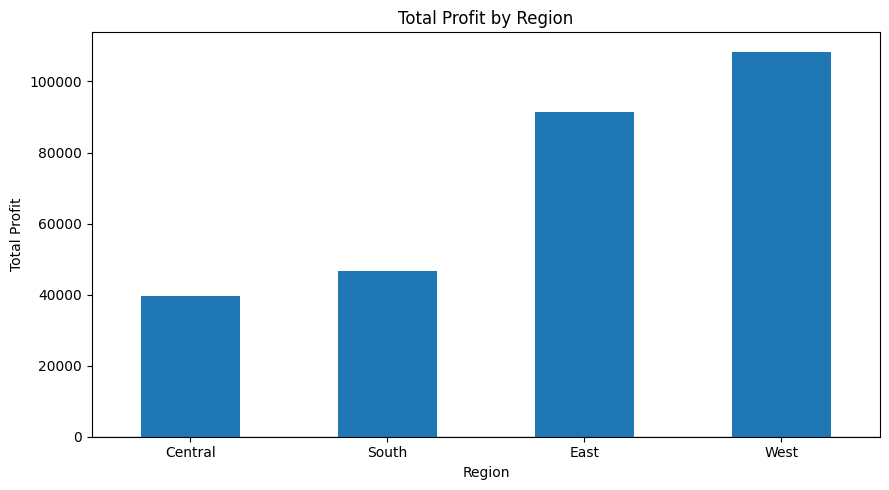

In [21]:
# Regional Sales and Profit Analysis

region_analysis = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).sort_values('Total_Profit', ascending=False)

print("Regional Performance Analysis")
display(region_analysis.round(2))

# Compare sales across regions
plt.figure(figsize=(9, 5))
region_analysis['Total_Sales'].sort_values().plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Compare profit across regions
plt.figure(figsize=(9, 5))
region_analysis['Total_Profit'].sort_values().plot(kind='bar')

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.axhline(y=0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:

# Customer Sales and Profit Analysis

customer_analysis = df.groupby('Customer Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Top 10 customers by sales
top_customers = customer_analysis.sort_values(
    'Total_Sales', ascending=False
).head(10)

print("Top 10 Customers by Sales")
display(top_customers.round(2))

# Visualize top customers
plt.figure(figsize=(11, 6))
plt.barh(
    top_customers['Customer Name'],
    top_customers['Total_Sales']
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Check whether top customers are profitable
print("Top Customers with Their Profit")
display(
    top_customers[
        ['Customer Name', 'Total_Sales', 'Total_Profit']
    ].round(2)
)

In [22]:

# Generate Key Business Insights

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

best_category = df.groupby('Category')['Profit'].sum().idxmax()
worst_category = df.groupby('Category')['Profit'].sum().idxmin()

best_region = df.groupby('Region')['Profit'].sum().idxmax()
worst_region = df.groupby('Region')['Profit'].sum().idxmin()

best_subcategory = df.groupby('Sub-Category')['Profit'].sum().idxmax()
worst_subcategory = df.groupby('Sub-Category')['Profit'].sum().idxmin()

best_product = df.groupby('Product Name')['Profit'].sum().idxmax()
worst_product = df.groupby('Product Name')['Profit'].sum().idxmin()

print("========== BUSINESS PERFORMANCE SUMMARY ==========")

print(f"\nTotal Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")

print("\n========== KEY FINDINGS ==========")
print(f"Most Profitable Category: {best_category}")
print(f"Least Profitable Category: {worst_category}")
print(f"Most Profitable Region: {best_region}")
print(f"Least Profitable Region: {worst_region}")
print(f"Most Profitable Sub-Category: {best_subcategory}")
print(f"Least Profitable Sub-Category: {worst_subcategory}")
print(f"Most Profitable Product: {best_product}")
print(f"Least Profitable Product: {worst_product}")

========== BUSINESS PERFORMANCE SUMMARY ==========

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%

========== KEY FINDINGS ==========
Most Profitable Category: Technology
Least Profitable Category: Furniture
Most Profitable Region: West
Least Profitable Region: Central
Most Profitable Sub-Category: Copiers
Least Profitable Sub-Category: Tables
Most Profitable Product: Canon imageCLASS 2200 Advanced Copier
Least Profitable Product: Cubify CubeX 3D Printer Double Head Print


## Business Recommendations

Based on the sales and profit analysis, the following recommendations can help improve business performance:

1. **Focus on Profitable Categories:** Identify the categories generating the highest profit and maintain sufficient inventory for products with strong demand.

2. **Review Low-Profit Categories:** Investigate categories and sub-categories with low profitability. Review product costs, pricing strategies, and operating expenses.

3. **Optimize Discount Strategies:** Evaluate the relationship between discounts and profit. Avoid offering excessive discounts on products with low profit margins.

4. **Improve Regional Performance:** Compare sales and profitability across regions. Develop targeted marketing strategies for regions with growth potential.

5. **Review Loss-Making Products:** Examine products generating negative profit. Review their pricing, discount levels, shipping costs, and overall demand before deciding on corrective actions.

6. **Strengthen Customer Relationships:** Identify valuable customers and encourage repeat purchases through targeted offers and customer-retention strategies.

7. **Monitor Business KPIs:** Regularly track total sales, total profit, profit margin, order volume, and regional performance to support data-driven decisions.


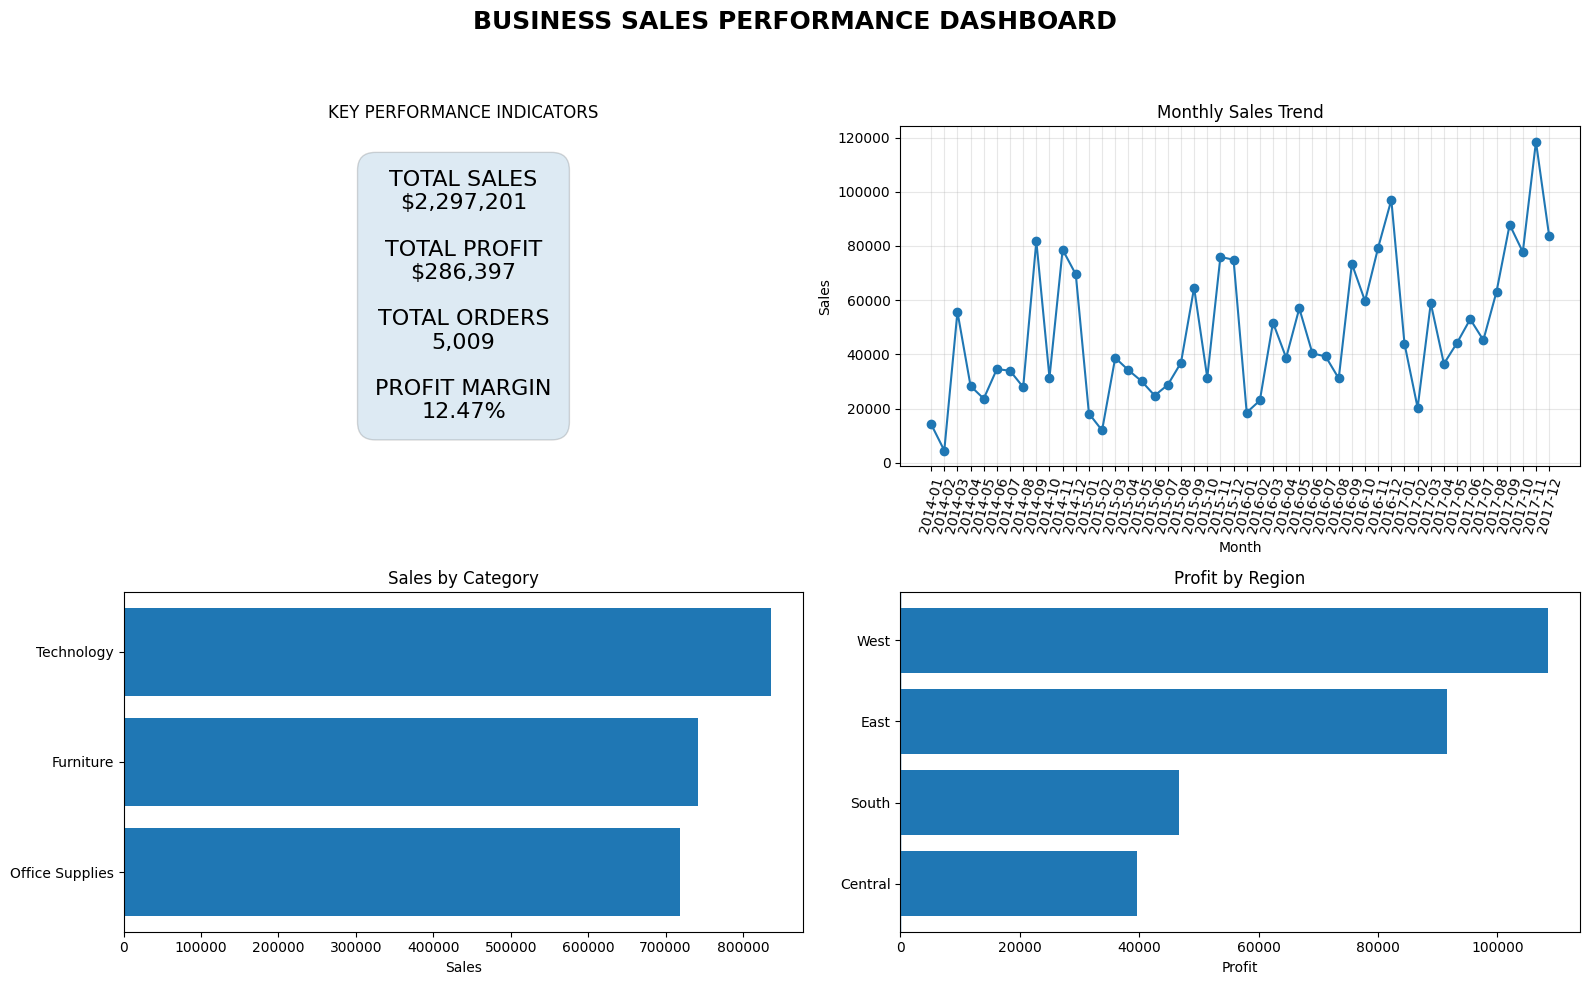

In [23]:

# Professional Business Sales Performance Dashboard

import matplotlib.pyplot as plt
import pandas as pd

# Calculate key performance indicators
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
profit_margin = (total_profit / total_sales) * 100

# Create dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'BUSINESS SALES PERFORMANCE DASHBOARD',
    fontsize=18,
    fontweight='bold'
)

# KPI summary
kpi_text = (
    f"TOTAL SALES\n${total_sales:,.0f}\n\n"
    f"TOTAL PROFIT\n${total_profit:,.0f}\n\n"
    f"TOTAL ORDERS\n{total_orders:,}\n\n"
    f"PROFIT MARGIN\n{profit_margin:.2f}%"
)

axes[0, 0].axis('off')
axes[0, 0].text(
    0.5, 0.5, kpi_text,
    ha='center', va='center',
    fontsize=16,
    bbox=dict(boxstyle='round,pad=0.8', alpha=0.15)
)
axes[0, 0].set_title('KEY PERFORMANCE INDICATORS')

# Monthly sales trend
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
)
monthly_sales.index = monthly_sales.index.astype(str)

axes[0, 1].plot(monthly_sales.index, monthly_sales.values, marker='o')
axes[0, 1].set_title('Monthly Sales Trend')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Sales')
axes[0, 1].tick_params(axis='x', rotation=75)
axes[0, 1].grid(True, alpha=0.3)

# Sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
axes[1, 0].barh(category_sales.index, category_sales.values)
axes[1, 0].set_title('Sales by Category')
axes[1, 0].set_xlabel('Sales')

# Profit by region
region_profit = df.groupby('Region')['Profit'].sum().sort_values()
axes[1, 1].barh(region_profit.index, region_profit.values)
axes[1, 1].set_title('Profit by Region')
axes[1, 1].set_xlabel('Profit')
axes[1, 1].axvline(x=0, linewidth=1)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Business Sales Performance Analytics

## 1. Project Overview

This project focuses on analyzing business sales data to understand sales trends, profitability, product performance, regional performance, and customer contribution. Python was used to analyze the dataset and create visualizations that support business decision-making.

## 2. Project Objectives

* Analyze overall sales and profit performance.
* Identify monthly sales trends.
* Compare sales and profit across product categories and sub-categories.
* Evaluate regional business performance.
* Identify loss-making products.
* Examine the relationship between discounts and profitability.
* Develop data-driven business recommendations.

## 3. Dataset Description

The project uses the Sample Superstore dataset. It contains information about orders, customers, products, sales, discounts, profits, shipping dates, and geographical regions.

## 4. Tools and Technologies

* Python
* Google Colab
* Pandas
* Matplotlib
* Data visualization and exploratory data analysis (EDA)

## 5. Methodology

The analysis was performed through the following stages:

1. Imported the dataset into Google Colab.
2. Inspected the dataset structure and checked missing values and duplicate records.
3. Converted date columns into the appropriate date format.
4. Calculated key performance indicators, including total sales, total profit, order count, and profit margin.
5. Analyzed monthly sales trends, category performance, regional performance, customer contribution, and product profitability.
6. Examined discount levels and their relationship with profit.
7. Created visualizations and a combined business performance dashboard.
8. Developed recommendations based on the analysis.

## 6. Key Findings

The analysis examines overall sales and profit, monthly sales trends, category-wise performance, regional profitability, customer contribution, and loss-making products.

The exact findings are presented in the output tables, charts, and KPI dashboard generated by the notebook.

## 7. Business Recommendations

* Prioritize products and categories with strong profitability.
* Investigate low-profit and loss-making products.
* Review discount strategies to protect profit margins.
* Identify regions with opportunities for improved profitability.
* Build customer-retention strategies using customer sales analysis.
* Monitor key performance indicators regularly.

## 8. Conclusion

This project demonstrates how Python-based data analysis and visualization can help businesses understand sales performance and profitability. The analysis provides a foundation for identifying business opportunities, reviewing pricing and discount strategies, and making data-driven decisions.

## 9. Future Scope

The project can be extended by developing an interactive dashboard in Power BI or Tableau, adding more advanced forecasting methods, and automating regular sales performance reports.


In [8]:

# Final Business Insights Table

category_profit = df.groupby('Category')['Profit'].sum()
region_profit = df.groupby('Region')['Profit'].sum()
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum()
product_profit = df.groupby('Product Name')['Profit'].sum()

insights = pd.DataFrame({
    'Business Area': [
        'Product Category',
        'Region',
        'Sub-Category',
        'Product'
    ],
    'Best Performer': [
        category_profit.idxmax(),
        region_profit.idxmax(),
        subcategory_profit.idxmax(),
        product_profit.idxmax()
    ],
    'Lowest Performer': [
        category_profit.idxmin(),
        region_profit.idxmin(),
        subcategory_profit.idxmin(),
        product_profit.idxmin()
    ],
    'Highest Profit': [
        category_profit.max(),
        region_profit.max(),
        subcategory_profit.max(),
        product_profit.max()
    ],
    'Lowest Profit': [
        category_profit.min(),
        region_profit.min(),
        subcategory_profit.min(),
        product_profit.min()
    ]
})

print("FINAL BUSINESS INSIGHTS")
display(insights.round(2))

FINAL BUSINESS INSIGHTS


,Business Area,Best Performer,Lowest Performer,Highest Profit,Lowest Profit
0,Product Category,Technology,Furniture,145454.95,18451.27
1,Region,West,Central,108418.45,39706.36
2,Sub-Category,Copiers,Tables,55617.82,-17725.48
3,Product,Canon imageCLASS 2200 Advanced Copier,Cubify CubeX 3D Printer Double Head Print,25199.93,-8879.97


In [9]:
# Save Final Business Insights

insights.to_csv(
    "final_business_insights.csv",
    index=False
)

print("Business insights saved successfully!")

Business insights saved successfully!


## Key Findings from the Data Analysis

1. **Category Performance:** Technology generated the highest profit among the product categories, while Furniture had the lowest profit.

2. **Regional Performance:** The West region recorded the highest total profit, whereas the Central region recorded the lowest total profit.

3. **Sub-Category Performance:** Copiers generated the highest total profit among the sub-categories. Tables recorded the lowest total profit and showed a negative profit value.

4. **Product Performance:** Canon imageCLASS 2200 Advanced Copier was the most profitable product by total profit. Cubify CubeX 3D Printer Double Head Print recorded the lowest total profit among the products analyzed.

5. **Business Opportunity:** The business should investigate the reasons behind low or negative profitability, including discounts, product costs, pricing, and shipping expenses.


## Overall Business Performance

The Sample Superstore analysis recorded total sales of approximately $2.30 million and total profit of approximately $286,397 across 5,009 distinct orders. The overall profit margin was approximately 12.47%.

The dashboard shows monthly sales fluctuations, differences in category-level sales, and variations in regional profitability. These results highlight the importance of monitoring both sales volume and profitability when making business decisions.


In [10]:

from google.colab import files

files.download("final_business_insights.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Key Findings from the Analysis

1. **Category Performance:** Technology was the most profitable category, generating a total profit of $145,454.95. Furniture had the lowest category profit, at $18,451.27.

2. **Regional Performance:** The West region generated the highest profit of $108,418.45. The Central region had the lowest regional profit of $39,706.36.

3. **Sub-Category Performance:** Copiers generated the highest sub-category profit of $55,617.82. Tables recorded a loss of $17,725.48, making them an important area for further investigation.

4. **Product Performance:** Canon imageCLASS 2200 Advanced Copier was the most profitable product, with a profit of $25,199.93. Cubify CubeX 3D Printer Double Head Print recorded the lowest product profit, at -$8,879.97.

## Data-Driven Recommendations

* Maintain effective inventory and marketing strategies for profitable Technology products.
* Investigate Furniture's relatively low profit and identify opportunities to improve its margins.
* Review the Tables sub-category's pricing, discounts, shipping costs, and product demand.
* Investigate the losses associated with the Cubify CubeX 3D Printer before deciding whether to adjust its pricing, promotions, or inventory.
* Study the successful sales and profitability strategies used in the West region to identify practices that may help improve other regions.
* Monitor profit, sales, and discount levels regularly to support better business decisions.
